<a href="https://colab.research.google.com/github/AntonRvn/ISLR-recognizer/blob/main/IRSL_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q ijson pyarrow
!pip install optuna
!pip install joblib
!pip install psutil

In [14]:
from google.colab import drive
from google.colab import files

import time
import joblib
import ijson
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import optuna
import psutil
import random
import seaborn as sns

from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from pathlib import Path
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, top_k_accuracy_score, precision_recall_fscore_support, confusion_matrix
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
JSON_PATH = Path("/content/drive/MyDrive/slovo_mediapipe.json")
ANNOTATIONS_PATH = Path("/content/drive/MyDrive/annotations.csv")

annotations = pd.read_csv(ANNOTATIONS_PATH, sep='\t')
annotations['attachment_id'] = annotations['attachment_id'].astype(str)

annotations = annotations[annotations['text'] != 'no_event']
annotations = annotations.reset_index(drop=True)

label_encoder = LabelEncoder()
annotations['label'] = label_encoder.fit_transform(annotations['text'])
num_classes = annotations['label'].nunique()
print(f"Количество классов: {num_classes}")

label_map = dict(zip(annotations['attachment_id'], annotations['label']))
split_map = dict(zip(annotations['attachment_id'], annotations['train']))

Количество классов: 1000


In [17]:
print("Сбор статистики длин последовательностей...")

all_lengths = []
video_lengths_dict = {}

with open(JSON_PATH, 'rb') as f:
    parser = ijson.kvitems(f, '')

    for attachment_id, frames in tqdm(parser):
        attachment_id = str(attachment_id)

        if attachment_id not in label_map:
            continue
        if not isinstance(frames, list):
            continue

        valid_frames = 0
        for frame in frames:
            if isinstance(frame, dict):
                valid_frames += 1

        if valid_frames > 0:
            all_lengths.append(valid_frames)
            video_lengths_dict[attachment_id] = valid_frames

print(f"Всего видео: {len(all_lengths)}")
print(f"Минимальная длина: {np.min(all_lengths)}")
print(f"Средняя длина: {np.mean(all_lengths):.2f}")
print(f"Медианная длина: {np.median(all_lengths):.2f}")
print(f"Максимальная длина: {np.max(all_lengths)}")
print(f"Стандартное отклонение: {np.std(all_lengths):.2f}")

percentiles = [50, 75, 85, 90, 95, 97, 99]
print("\nПЕРЦЕНТИЛИ:")
for p in percentiles:
    val = np.percentile(all_lengths, p)
    print(f"  {p}%: {val:.0f} кадров")

p75 = int(np.percentile(all_lengths, 75))
p95 = int(np.percentile(all_lengths, 95))
p99 = int(np.percentile(all_lengths, 99))

TARGET_LEN = 55

print(f"\nВыбран TARGET_LEN = {TARGET_LEN}")
print(f"Видео длиной {p95} кадров будет сжато до {TARGET_LEN} кадров")

video_shorter = sum(1 for l in all_lengths if l < TARGET_LEN)
video_longer = sum(1 for l in all_lengths if l > TARGET_LEN)
video_equal = sum(1 for l in all_lengths if l == TARGET_LEN)

total = len(all_lengths)
print(f"\nПри TARGET_LEN = {TARGET_LEN}:")
print(f"  - Видео короче (будут растянуты): {video_shorter} ({video_shorter/total*100:.1f}%)")
print(f"  - Видео длиннее (будут сжаты): {video_longer} ({video_longer/total*100:.1f}%)")
print(f"  - Видео с точной длиной: {video_equal} ({video_equal/total*100:.1f}%)")

Сбор статистики длин последовательностей...


20000it [00:58, 342.78it/s]


Всего видео: 19990
Минимальная длина: 1
Средняя длина: 46.79
Медианная длина: 45.00
Максимальная длина: 236
Стандартное отклонение: 16.44

ПЕРЦЕНТИЛИ:
  50%: 45 кадров
  75%: 54 кадров
  85%: 61 кадров
  90%: 66 кадров
  95%: 74 кадров
  97%: 81 кадров
  99%: 98 кадров

Выбран TARGET_LEN = 55
Видео длиной 74 кадров будет сжато до 55 кадров

При TARGET_LEN = 55:
  - Видео короче (будут растянуты): 15051 (75.3%)
  - Видео длиннее (будут сжаты): 4571 (22.9%)
  - Видео с точной длиной: 368 (1.8%)


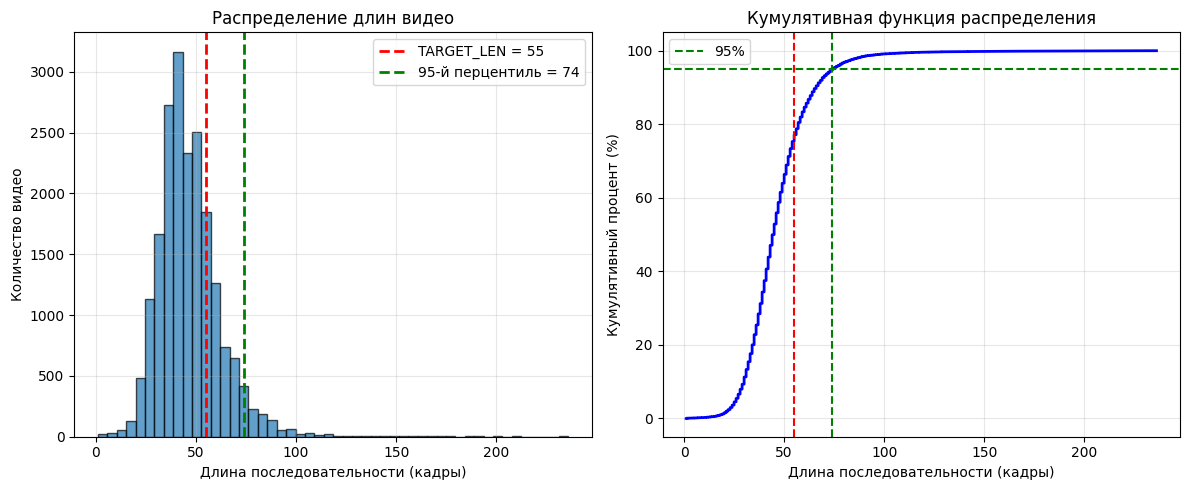

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(all_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(TARGET_LEN, color='red', linestyle='--', linewidth=2, label=f'TARGET_LEN = {TARGET_LEN}')
plt.axvline(p95, color='green', linestyle='--', linewidth=2, label=f'95-й перцентиль = {p95}')
plt.xlabel('Длина последовательности (кадры)')
plt.ylabel('Количество видео')
plt.title('Распределение длин видео')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sorted_lengths = np.sort(all_lengths)
cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100
plt.plot(sorted_lengths, cumulative, 'b-', linewidth=2)
plt.axhline(95, color='green', linestyle='--', label='95%')
plt.axvline(p95, color='green', linestyle='--')
plt.axvline(TARGET_LEN, color='red', linestyle='--')
plt.xlabel('Длина последовательности (кадры)')
plt.ylabel('Кумулятивный процент (%)')
plt.title('Кумулятивная функция распределения')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
def uniform_sampling(sequence, target_len=TARGET_LEN):
    '''Сжатие/растяжение последовательностей (последний шаг предобработки)'''
    current_len = len(sequence)

    if current_len == target_len:
        return sequence

    indices = np.linspace(0, current_len - 1, target_len)
    result = []
    for i in indices:
        i0 = int(np.floor(i))
        i1 = int(np.ceil(i))

        if i0 == i1:
            result.append(sequence[i0])
        else:
            alpha = i - i0
            interpolated = (1 - alpha) * sequence[i0] + alpha * sequence[i1]
            result.append(interpolated)

    return np.array(result)

# Тест функции
test_lengths = [30, 50, 75, 100, 150, 200, TARGET_LEN]
for test_len in test_lengths:
    test_seq = np.random.rand(test_len, 126)
    result = uniform_sampling(test_seq, TARGET_LEN)
    print(f"  {test_len:3d} кадров → {len(result):3d} кадров ({'растяжение' if test_len < TARGET_LEN else 'сжатие' if test_len > TARGET_LEN else 'без изменений'})")

   30 кадров →  55 кадров (растяжение)
   50 кадров →  55 кадров (растяжение)
   75 кадров →  55 кадров (сжатие)
  100 кадров →  55 кадров (сжатие)
  150 кадров →  55 кадров (сжатие)
  200 кадров →  55 кадров (сжатие)
   55 кадров →  55 кадров (без изменений)


In [62]:
def add_motion_features_2d(seq):

    T = seq.shape[0]
    features = seq.shape[1]

    velocity = np.zeros((T, features))
    acceleration = np.zeros((T, features))

    if T > 1:
        velocity = np.diff(seq, axis=0, prepend=seq[0:1, :])

        if T > 2:
            acceleration = np.diff(velocity, axis=0, prepend=velocity[0:1, :])

    return np.concatenate([seq, velocity, acceleration], axis=1)


In [63]:
print(f"\nОбработка JSON с TARGET_LEN = {TARGET_LEN}")

official_train_sequences = []
official_train_labels = []
official_test_sequences = []
official_test_labels = []

lengths_before = []
lengths_after = []

invalid_points = 0

print("Начинаю обработку JSON...")

with open(JSON_PATH, 'rb') as f:
    parser = ijson.kvitems(f, '')

    for attachment_id, frames in tqdm(parser):
        attachment_id = str(attachment_id)

        if attachment_id not in label_map:
            continue
        if not isinstance(frames, list):
            continue

        sequence = []

        for frame in frames:
            if not isinstance(frame, dict):
                continue

            frame_vector = []

            for hand_name in ['hand 1', 'hand 2']:
                landmarks = frame.get(hand_name)

                if landmarks is None or not isinstance(landmarks, list):
                    frame_vector.extend([0.0] * 63)
                    continue

                if len(landmarks) != 21:
                    invalid_points += 1

                coords = []
                for point in landmarks[:21]:
                    try:
                        coords.append([float(point['x']), float(point['y']), float(point['z'])])
                    except Exception:
                        coords.append([0.0, 0.0, 0.0])

                coords = np.array(coords, dtype=np.float32)

                wrist = coords[0]
                coords = coords - wrist

                distances = np.linalg.norm(coords, axis=1, keepdims=True)
                coords = np.concatenate([coords, distances], axis=1)

                coords = coords.flatten().tolist()
                coords = coords[:63]
                coords += [0.0] * (63 - len(coords))

                frame_vector.extend(coords)

            sequence.append(frame_vector)

        if len(sequence) == 0:
            continue

        original_len = len(sequence)
        lengths_before.append(original_len)

        sequence_array = np.array(sequence, dtype=np.float32)
        sequence_with_motion = add_motion_features_2d(sequence_array)

        sequence_target = uniform_sampling(sequence_with_motion, TARGET_LEN)
        lengths_after.append(len(sequence_target))

        label = label_map[attachment_id]
        is_train = split_map[attachment_id]

        if is_train:
            official_train_sequences.append(sequence_target)
            official_train_labels.append(label)
        else:
            official_test_sequences.append(sequence_target)
            official_test_labels.append(label)

print("\nОбработка завершена")
print(f"Официальный Train samples: {len(official_train_sequences)}")
print(f"Официальный Test samples: {len(official_test_sequences)}")
print(f"Всего обработано: {len(lengths_before)} видео")
print(f"Невалидных точек: {invalid_points}")


Обработка JSON с TARGET_LEN = 55
Начинаю обработку JSON...


20000it [02:28, 134.83it/s]


Обработка завершена
Официальный Train samples: 14992
Официальный Test samples: 4998
Всего обработано: 19990 видео
Невалидных точек: 0



СРАВНЕНИЕ ДЛИН ДО И ПОСЛЕ ОБРАБОТКИ

          Показатель           |  ДО обработки   | ПОСЛЕ обработки
-----------------------------------------------------------------
      Минимальная длина        |        1        |       55       
      Максимальная длина       |       236       |       55       
        Средняя длина          |      46.79      |      55.00     
       Медианная длина         |      45.00      |      55.00     
      Станд. отклонение        |      16.44      |      0.00      

Уникальные длины после обработки: [55]
Все видео имеют одинаковую длину: True (55 кадров)


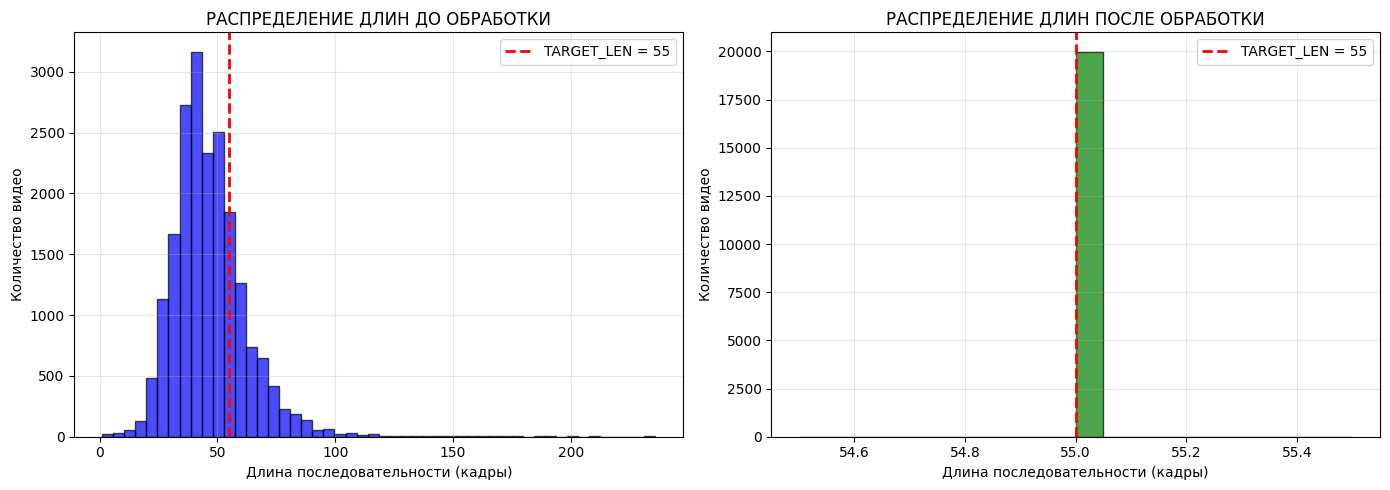


Статистика трансформации:
  - Сжато (уменьшено): 4571 (22.9%)
  - Растянуто (увеличено): 15051 (75.3%)
  - Оставлено без изменений: 368 (1.8%)


In [64]:
lengths_before = np.array(lengths_before)
lengths_after = np.array(lengths_after)


print(f"\n{'Показатель':^30} | {'ДО обработки':^15} | {'ПОСЛЕ обработки':^15}")
print("-" * 65)
print(f"{'Минимальная длина':^30} | {np.min(lengths_before):^15} | {np.min(lengths_after):^15}")
print(f"{'Максимальная длина':^30} | {np.max(lengths_before):^15} | {np.max(lengths_after):^15}")
print(f"{'Средняя длина':^30} | {np.mean(lengths_before):^15.2f} | {np.mean(lengths_after):^15.2f}")
print(f"{'Медианная длина':^30} | {np.median(lengths_before):^15.2f} | {np.median(lengths_after):^15.2f}")
print(f"{'Станд. отклонение':^30} | {np.std(lengths_before):^15.2f} | {np.std(lengths_after):^15.2f}")

unique_after = np.unique(lengths_after)
print(f"\nУникальные длины после обработки: {unique_after}")
print(f"Все видео имеют одинаковую длину: {len(unique_after) == 1} ({TARGET_LEN} кадров)")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(lengths_before, bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].axvline(TARGET_LEN, color='red', linestyle='--', linewidth=2, label=f'TARGET_LEN = {TARGET_LEN}')
axes[0].set_xlabel('Длина последовательности (кадры)')
axes[0].set_ylabel('Количество видео')
axes[0].set_title('РАСПРЕДЕЛЕНИЕ ДЛИН ДО ОБРАБОТКИ')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(lengths_after, bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(TARGET_LEN, color='red', linestyle='--', linewidth=2, label=f'TARGET_LEN = {TARGET_LEN}')
axes[1].set_xlabel('Длина последовательности (кадры)')
axes[1].set_ylabel('Количество видео')
axes[1].set_title('РАСПРЕДЕЛЕНИЕ ДЛИН ПОСЛЕ ОБРАБОТКИ')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика трансформации
compressed = sum(1 for before, after in zip(lengths_before, lengths_after) if before > after)
expanded = sum(1 for before, after in zip(lengths_before, lengths_after) if before < after)
unchanged = sum(1 for before, after in zip(lengths_before, lengths_after) if before == after)

total = len(lengths_before)
print(f"\nСтатистика трансформации:")
print(f"  - Сжато (уменьшено): {compressed} ({compressed/total*100:.1f}%)")
print(f"  - Растянуто (увеличено): {expanded} ({expanded/total*100:.1f}%)")
print(f"  - Оставлено без изменений: {unchanged} ({unchanged/total*100:.1f}%)")

In [78]:
X_official_train = np.array(official_train_sequences, dtype=np.float32)
y_official_train = np.array(official_train_labels)
X_test = np.array(official_test_sequences, dtype=np.float32)
y_test = np.array(official_test_labels)

print(f"X_official_train shape: {X_official_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Разделение на train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_official_train, y_official_train,
    test_size=0.2,
    random_state=42,
    stratify=y_official_train
)


X_official_train shape: (14992, 55, 378)
X_test shape: (4998, 55, 378)


In [66]:
n_samples_train, n_timesteps, n_features = X_train.shape

X_train_2d = X_train.reshape(-1, n_features)
X_val_2d = X_val.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)
X_val_scaled = scaler.transform(X_val_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train_norm = X_train_scaled.reshape(X_train.shape)
X_val_norm = X_val_scaled.reshape(X_val.shape)
X_test_norm = X_test_scaled.reshape(X_test.shape)

In [67]:
class GestureDataset(Dataset):
    def __init__(self, X, y, augment=True, noise_std=0.02, scale_range=(0.95, 1.05),
                 translate_range=0.05, max_len=73):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.max_len = max_len
        self.lengths = torch.tensor((X.sum(axis=2) != 0).sum(axis=1), dtype=torch.long)
        self.lengths = torch.clamp(self.lengths, min=1)
        self.augment = augment
        self.noise_std = noise_std
        self.scale_range = scale_range
        self.translate_range = translate_range

    def __len__(self):
        return len(self.X)

    def apply_augmentations(self, sequence, length):
        seq = sequence.clone()

        if random.random() > 0.5:
            scale = random.uniform(*self.scale_range)
            seq = seq * scale

        if random.random() > 0.5:
            translation = random.uniform(-self.translate_range, self.translate_range)
            seq = seq + translation

        if random.random() > 0.5:
            noise = torch.randn_like(seq) * self.noise_std
            mask = torch.zeros_like(seq)
            mask[:length] = 1.0
            seq = seq + noise * mask

        return seq

    def __getitem__(self, idx):
        X_seq = self.X[idx]
        y_label = self.y[idx]
        length = self.lengths[idx].item()

        if self.augment:
            X_seq = self.apply_augmentations(X_seq, length)

        return X_seq, y_label, length

In [68]:
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size=378,
        conv_channels=128,
        kernel_size=3,
        hidden_size=256,
        num_layers=2,
        num_classes=1000,
        dropout=0.25
    ):
        super().__init__()

        # Conv1D
        self.conv1 = nn.Conv1d(
            input_size, conv_channels, kernel_size=kernel_size, padding=kernel_size // 2
        )
        self.conv_bn = nn.BatchNorm1d(conv_channels)
        self.conv_dropout = nn.Dropout(dropout)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        # Attention
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        self.dropout = nn.Dropout(dropout)

        # Линейные слои
        self.fc1 = nn.Linear(hidden_size * 2, 256)
        self.fc1_bn = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x, lengths):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv_bn(x)
        x = torch.relu(x)
        x = self.conv_dropout(x)
        x = x.transpose(1, 2)

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_output, _ = self.lstm(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)

        attn_weights = self.attention(output).squeeze(-1)
        mask = torch.arange(output.size(1), device=output.device)[None, :] < lengths[:, None]
        attn_weights = attn_weights.masked_fill(~mask, -1e9)
        attn_weights = torch.softmax(attn_weights, dim=1)
        pooled = (output * attn_weights.unsqueeze(-1)).sum(dim=1)
        pooled = self.dropout(pooled)

        x = self.fc1(pooled)
        x = self.fc1_bn(x)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.fc2(x)

        return logits

In [69]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

final_params = {
    'dropout': 0.61,
    'lr': 0.0024,
    'weight_decay': 0.00025,
    'hidden_size': 256,
    'conv_channels': 64,
    'num_layers': 1,
    'label_smoothing': 0.1
}

print("Финальное обучение модели с лучшими параметрами")
for key, value in final_params.items():
    print(f"{key} : {value}")

train_dataset = GestureDataset(X_train_norm, y_train, augment=False)
val_dataset = GestureDataset(X_val_norm, y_val, augment=False)
test_dataset = GestureDataset(X_test_norm, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

model = LSTMClassifier(
    input_size=378,
    conv_channels=final_params['conv_channels'],
    kernel_size=3,
    hidden_size=final_params['hidden_size'],
    num_layers=final_params['num_layers'],
    num_classes=num_classes,
    dropout=final_params['dropout']
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=final_params['label_smoothing'])
optimizer = torch.optim.Adam(model.parameters(),
                             lr=final_params['lr'],
                             weight_decay=final_params['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

Device: cuda
Финальное обучение модели с лучшими параметрами
dropout : 0.61
lr : 0.0024
weight_decay : 0.00025
hidden_size : 256
conv_channels : 64
num_layers : 1
label_smoothing : 0.1


In [70]:
EPOCHS = 250
best_val_f1 = 0
patience = 15
patience_counter = 0


print(f"\n{'Epoch':^6} | {'Train Loss':^10} | {'Train Top-1':^10} | {'Train F1':^10} | {'Train Top-5':^10} | "
      f"{'Val Top-1':^10} | {'Val F1':^10} | {'Val Top-5':^10}")
print("-" * 110)

save_path = '/content/drive/MyDrive/slovo_models/best_model.pt'

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_preds = []
    train_targets = []
    train_probs = []

    for X_batch, y_batch, lengths in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()
        logits = model(X_batch, lengths)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_targets.extend(y_batch.detach().cpu().numpy())
        train_probs.extend(probs.detach().cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    train_top1_acc = 100. * np.mean(np.array(train_preds) == np.array(train_targets))
    train_f1 = f1_score(train_targets, train_preds, average='macro', zero_division=0) * 100
    train_top5_acc = top_k_accuracy_score(train_targets, train_probs, k=5, labels=range(num_classes)) * 100

    model.eval()
    val_preds = []
    val_targets = []
    val_probs = []
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch, lengths in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            lengths = lengths.to(device)

            logits = model(X_batch, lengths)
            loss = criterion(logits, y_batch)
            val_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(y_batch.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_top1_acc = 100. * np.mean(np.array(val_preds) == np.array(val_targets))
    val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0) * 100
    val_top5 = top_k_accuracy_score(val_targets, val_probs, k=5, labels=range(num_classes)) * 100

    scheduler.step(val_f1)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:^6} | {avg_train_loss:^10.4f} | {train_top1_acc:^10.2f} | {train_f1:^10.2f} | {train_top5_acc:^10.2f} | "
              f"{val_top1_acc:^10.2f} | {val_f1:^10.2f} | {val_top5:^10.2f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_top1_acc = val_top1_acc
        best_val_top5 = val_top5
        best_train_f1 = train_f1
        best_train_top1_acc = train_top1_acc
        best_train_top5_acc = train_top5_acc
        best_epoch = epoch + 1

        # Сохраняем модель вместе со всей историей метрик
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'val_top1_acc': val_top1_acc,
            'val_top5': val_top5,
            'train_f1': train_f1,
            'train_top1_acc': train_top1_acc,
            'train_top5_acc': train_top5_acc,
            'params': final_params,
        }, save_path)
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping на эпохе {epoch+1}")
        break

print("\n" + "="*60)
print("ВАЛИДАЦИОННЫЕ МЕТРИКИ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)
print(f"Лучшая эпоха: {best_epoch}")
print(f"Train Top-1 Acc: {best_train_top1_acc:.2f}%")
print(f"Train F1 (macro): {best_train_f1:.2f}%")
print(f"Train Top-5 Acc: {best_train_top5_acc:.2f}%")
print(f"\nValidation Top-1 Acc: {best_val_top1_acc:.2f}%")
print(f"Validation F1 (macro): {best_val_f1:.2f}%")
print(f"Validation Top-5 Acc: {best_val_top5:.2f}%")



Epoch  | Train Loss | Train Top-1 |  Train F1  | Train Top-5 | Val Top-1  |   Val F1   | Val Top-5 
--------------------------------------------------------------------------------------------------------------
  1    |   7.0396   |    0.17    |    0.12    |    0.92    |    0.53    |    0.04    |    2.50   
  5    |   5.8874   |    1.43    |    1.08    |    6.97    |    3.63    |    1.21    |   12.84   
  10   |   5.0787   |    5.84    |    4.96    |   22.70    |   15.34    |   10.49    |   42.28   
  15   |   4.6461   |   11.38    |   10.26    |   35.74    |   22.01    |   16.95    |   54.05   
  20   |   4.3943   |   15.48    |   14.42    |   43.13    |   28.81    |   24.00    |   62.89   
  25   |   4.2361   |   17.58    |   16.39    |   48.06    |   31.34    |   26.74    |   67.06   
  30   |   4.1352   |   20.03    |   18.82    |   50.86    |   35.98    |   31.16    |   69.46   
  35   |   4.0312   |   21.78    |   20.69    |   54.04    |   36.41    |   31.85    |   71.76   
  40

In [71]:
print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)

checkpoint = torch.load(save_path, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

model.eval()
test_preds = []
test_targets = []
test_probs = []
test_loss = 0

with torch.no_grad():
    for X_batch, y_batch, lengths in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        lengths = lengths.to(device)

        logits = model(X_batch, lengths)
        loss = criterion(logits, y_batch)
        test_loss += loss.item()

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(y_batch.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

test_top1_acc = 100. * np.mean(np.array(test_preds) == np.array(test_targets))

macro_acc = 0
num_classes_with_samples = 0
for class_id in range(num_classes):
    mask = (np.array(test_targets) == class_id)
    if mask.sum() > 0:
        class_acc = (np.array(test_preds)[mask] == class_id).sum() / mask.sum()
        macro_acc += class_acc
        num_classes_with_samples += 1
macro_acc = (macro_acc / num_classes_with_samples) * 100 if num_classes_with_samples > 0 else 0

test_f1_macro = f1_score(test_targets, test_preds, average='macro', zero_division=0) * 100
test_top5 = top_k_accuracy_score(test_targets, test_probs, k=5, labels=range(num_classes)) * 100

print(f"\n{'Подвыборка':^15} | {'Top-1 Acc (%)':^15} | {'F1 (macro) (%)':^18} | {'Top-5 (%)':^12}")
print("-" * 90)
print(f"{'Train':^15} | {best_train_top1_acc:^15.2f} | {best_train_f1:^18.2f} | {best_train_top5_acc:^12.2f}")
print(f"{'Val':^15} | {best_val_top1_acc:^15.2f} | {best_val_f1:^18.2f} | {best_val_top5:^12.2f}")
print(f"{'Test':^15} | {test_top1_acc:^15.2f} | {test_f1_macro:^18.2f} | {test_top5:^12.2f}")


ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ

  Подвыборка    |  Top-1 Acc (%)  |   F1 (macro) (%)   |  Top-5 (%)  
------------------------------------------------------------------------------------------
     Train      |      66.96      |       66.29        |    92.92    
      Val       |      65.22      |       63.54        |    90.33    
     Test       |      50.50      |       49.05        |    80.05    



Классы с короткими видео (<50 кадров): 817 классов, средний F1 = 45.4%, средняя Accuracy = 46.8%
Классы со средними видео (50-100 кадров): 20 классов, средний F1 = 55.8%, средняя Accuracy = 63.0%
Классы с длинными видео (>100 кадров): 163 классов, средний F1 = 66.6%, средняя Accuracy = 67.4%


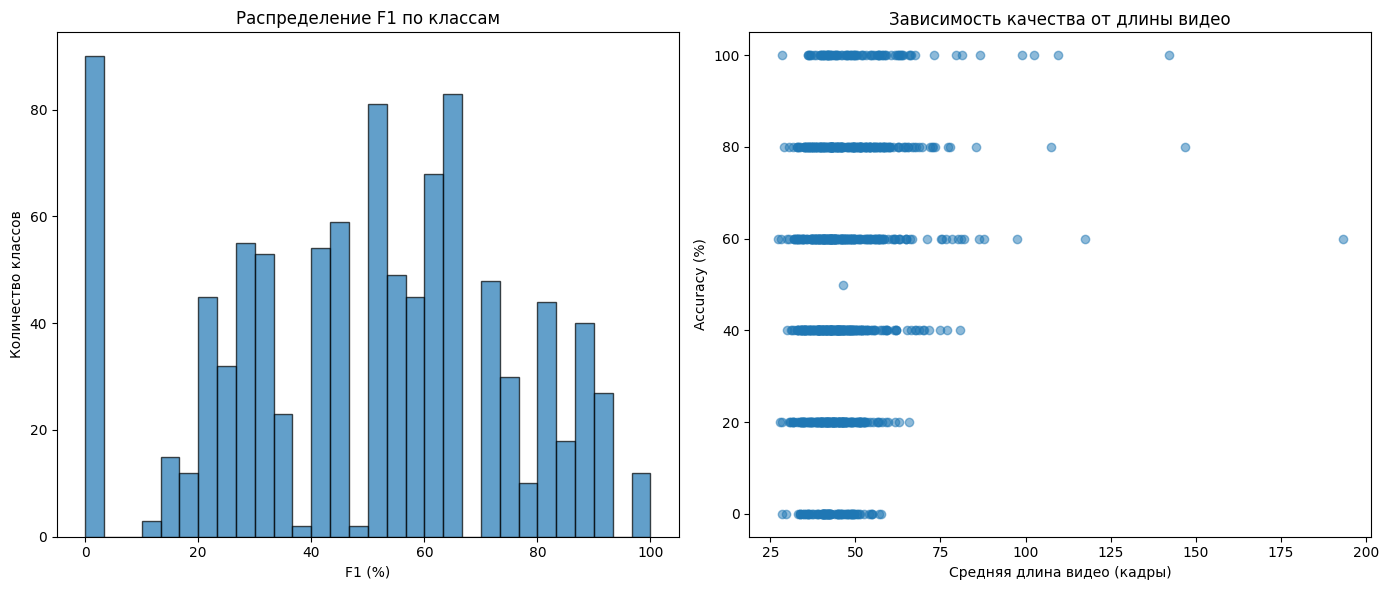

In [72]:
model.eval()
all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch, lengths in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        lengths = lengths.to(device)

        logits = model(X_batch, lengths)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)

class_names = label_encoder.inverse_transform(range(num_classes))

class_metrics = {}
for class_id in range(num_classes):
    mask = (all_targets == class_id)
    if mask.sum() == 0:
        continue

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, labels=[class_id], zero_division=0
    )

    class_acc = (all_preds[mask] == class_id).sum() / mask.sum()

    class_metrics[class_id] = {
        'name': class_names[class_id],
        'total': mask.sum(),
        'accuracy': class_acc,
        'precision': precision[0],
        'recall': recall[0],
        'f1': f1[0]
    }

class_to_ids = {}
for attachment_id, label in zip(annotations['attachment_id'], annotations['label']):
    if label not in class_to_ids:
        class_to_ids[label] = []
    class_to_ids[label].append(attachment_id)

class_lengths = {}
for class_id in range(num_classes):
    if class_id in class_to_ids:
        lengths = [video_lengths_dict.get(att_id, 0) for att_id in class_to_ids[class_id] if att_id in video_lengths_dict]
        if lengths:
            class_lengths[class_id] = {
                'mean_len': np.mean(lengths),
                'f1': class_metrics[class_id]['f1'] if class_id in class_metrics else 0,
                'accuracy': class_metrics[class_id]['accuracy'] if class_id in class_metrics else 0
            }

short_f1 = [class_lengths[c]['f1'] for c in class_lengths if class_lengths[c]['mean_len'] < 54]
medium_f1 = [class_lengths[c]['f1'] for c in class_lengths if 54 <= class_lengths[c]['mean_len'] < 55]
long_f1 = [class_lengths[c]['f1'] for c in class_lengths if class_lengths[c]['mean_len'] >= 55]

short_acc = [class_lengths[c]['accuracy'] for c in class_lengths if class_lengths[c]['mean_len'] < 54]
medium_acc = [class_lengths[c]['accuracy'] for c in class_lengths if 54 <= class_lengths[c]['mean_len'] < 55]
long_acc = [class_lengths[c]['accuracy'] for c in class_lengths if class_lengths[c]['mean_len'] >= 55]

print(f"\nКлассы с короткими видео (<50 кадров): {len(short_f1)} классов, средний F1 = {np.mean(short_f1)*100:.1f}%, средняя Accuracy = {np.mean(short_acc)*100:.1f}%")
print(f"Классы со средними видео (50-100 кадров): {len(medium_f1)} классов, средний F1 = {np.mean(medium_f1)*100:.1f}%, средняя Accuracy = {np.mean(medium_acc)*100:.1f}%")
print(f"Классы с длинными видео (>100 кадров): {len(long_f1)} классов, средний F1 = {np.mean(long_f1)*100:.1f}%, средняя Accuracy = {np.mean(long_acc)*100:.1f}%")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
f1_values = [m['f1']*100 for m in class_metrics.values()]
plt.hist(f1_values, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('F1 (%)')
plt.ylabel('Количество классов')
plt.title('Распределение F1 по классам')

plt.subplot(1, 2, 2)
f1_vs_length = [(class_lengths[c]['mean_len'], class_metrics[c]['accuracy']*100)
                for c in class_lengths if c in class_metrics]
if f1_vs_length:
    lengths_plot = [x[0] for x in f1_vs_length]
    f1_plot = [x[1] for x in f1_vs_length]
    plt.scatter(lengths_plot, f1_plot, alpha=0.5)
    plt.xlabel('Средняя длина видео (кадры)')
    plt.ylabel('Accuracy (%)')
    plt.title('Зависимость качества от длины видео')

plt.tight_layout()
plt.show()

ТОП-10 НАИБОЛЕЕ ЧАСТО ПУТАЕМЫХ ПАР ЖЕСТОВ

        Истинный жест          |       Предсказанный жест       |  Кол-во ошибок 
--------------------------------------------------------------------------------
           сначала             |             начало             |        5       
             мой               |            активный            |        4       
             семь              |            седьмой             |        4       
          пока (что)           |              Пока              |        4       
        переваривание          |             бумага             |        4       
          отложенный           |            отложить            |        4       
            взять              |            одолжить            |        4       
             ваш               |               вы               |        4       
         не выносить           |           ненавидеть           |        4       
           плакать             |          разрыдаться   

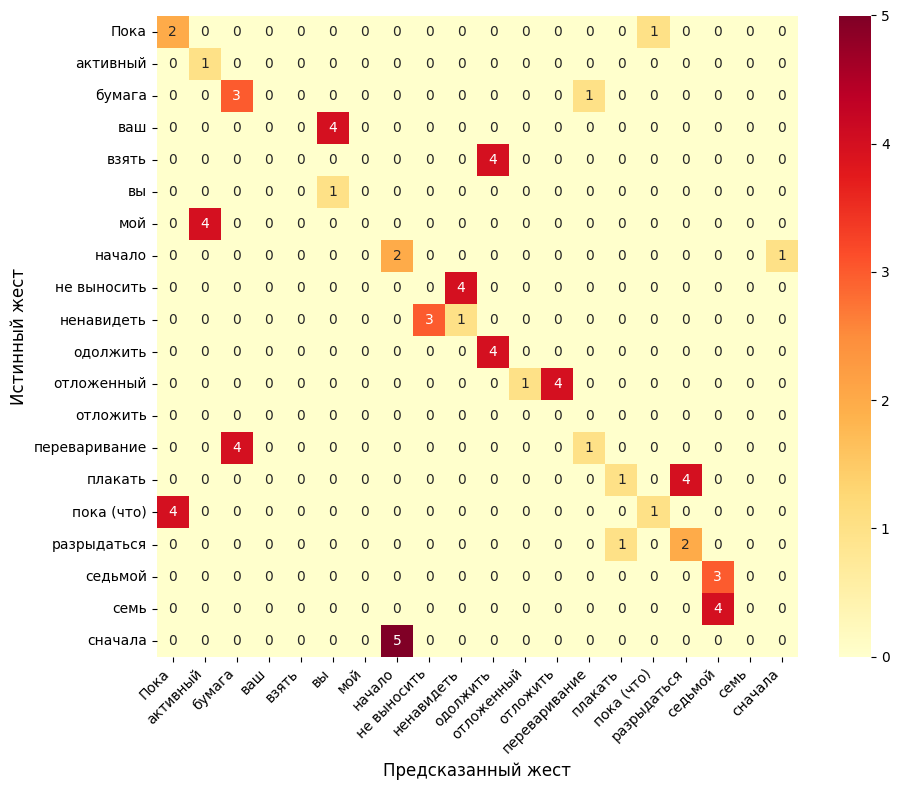


1. Истинный жест: 'сначала' → Предсказанный: 'начало'
   Количество ошибок: 5

   Информация об истинном жесте 'сначала':
     - Точность: 0.0%
     - F1: 0.0%
     - Средняя длина видео: 40.9 кадров

   Информация о предсказанном жесте 'начало':
     - Точность: 40.0%
     - F1: 30.8%
     - Средняя длина видео: 39.5 кадров

Возможные причины путаницы:
Похожая длина видео (41 vs 40 кадров)
 Истинный класс распознаётся плохо (0.0%) → возможно, мало данных или сложный жест
   ------------------------------------------------------------

2. Истинный жест: 'мой' → Предсказанный: 'активный'
   Количество ошибок: 4

   Информация об истинном жесте 'мой':
     - Точность: 0.0%
     - F1: 0.0%
     - Средняя длина видео: 35.9 кадров

   Информация о предсказанном жесте 'активный':
     - Точность: 20.0%
     - F1: 11.8%
     - Средняя длина видео: 45.0 кадров

Возможные причины путаницы:
Похожая длина видео (36 vs 45 кадров)
 Истинный класс распознаётся плохо (0.0%) → возможно, мало данных и

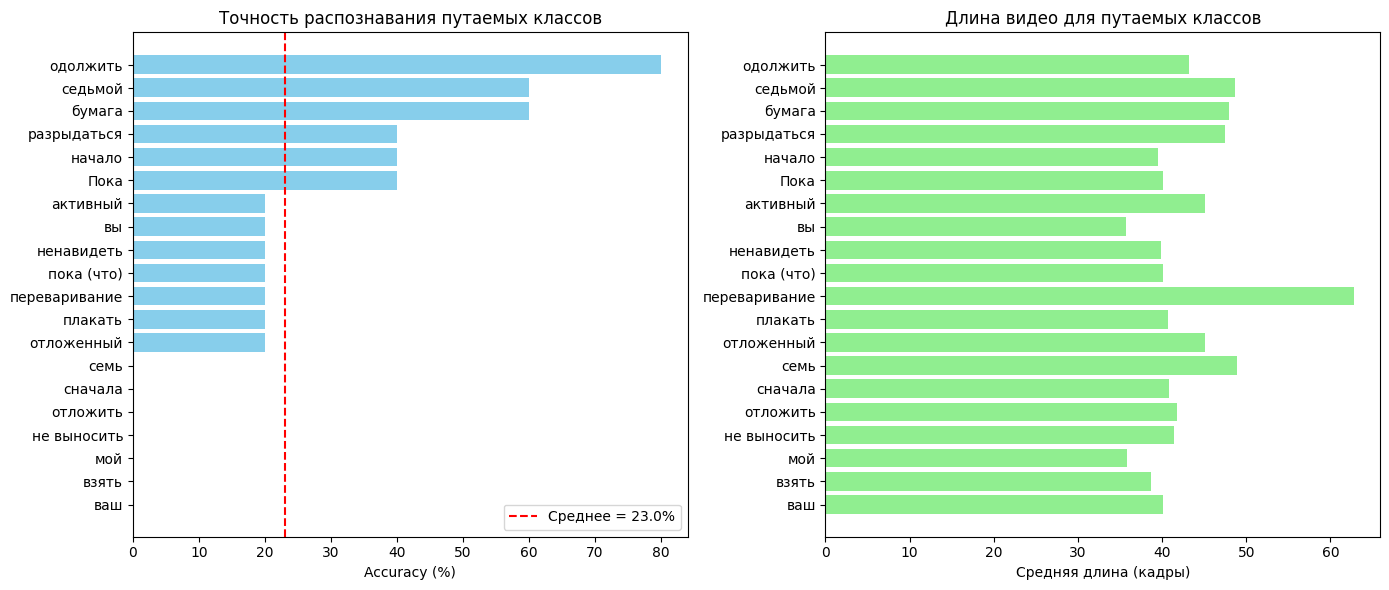

In [77]:
cm = confusion_matrix(all_targets, all_preds)

confusion_pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'true_class_id': i,
                'true_class_name': class_names[i],
                'pred_class_id': j,
                'pred_class_name': class_names[j],
                'error_count': cm[i, j]
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs).sort_values('error_count', ascending=False)

top_confusions = confusion_pairs_df.head(10)

print("ТОП-10 НАИБОЛЕЕ ЧАСТО ПУТАЕМЫХ ПАР ЖЕСТОВ")
print(f"\n{'Истинный жест':^30} | {'Предсказанный жест':^30} | {'Кол-во ошибок':^15}")
print("-"*80)

for _, row in top_confusions.iterrows():
    print(f"{row['true_class_name']:^30} | {row['pred_class_name']:^30} | {row['error_count']:^15}")

confused_classes = set()
for _, row in top_confusions.iterrows():
    confused_classes.add(row['true_class_id'])
    confused_classes.add(row['pred_class_id'])

confused_classes = sorted(list(confused_classes))
print(f"\nКлассы, участвующие в частых путаницах: {len(confused_classes)}")

cm_reduced = cm[np.ix_(confused_classes, confused_classes)]
labels_reduced = [class_names[i] for i in confused_classes]

plt.figure(figsize=(max(10, len(confused_classes) * 0.4),
                    max(8, len(confused_classes) * 0.4)))
sns.heatmap(cm_reduced,
            annot=True,
            fmt='d',
            xticklabels=labels_reduced,
            yticklabels=labels_reduced,
            cmap='YlOrRd',
            square=True)
plt.xlabel('Предсказанный жест', fontsize=12)
plt.ylabel('Истинный жест', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


def get_class_info(class_id):
    """Собирает информацию о классе для анализа"""
    info = {
        'name': class_names[class_id],
        'id': class_id,
        'total_examples': class_metrics[class_id]['total'],
        'accuracy': class_metrics[class_id]['accuracy'] * 100,
        'f1': class_metrics[class_id]['f1'] * 100,
        'mean_len': class_lengths.get(class_id, {}).get('mean_len', 0)
    }

    errors = []
    for j in range(num_classes):
        if j != class_id and cm[class_id, j] > 0:
            errors.append((class_names[j], cm[class_id, j]))

    errors_sorted = sorted(errors, key=lambda x: x[1], reverse=True)[:5]
    info['top_confusions'] = errors_sorted

    return info

for i, (idx, row) in enumerate(top_confusions.head(5).iterrows()):
    true_class = row['true_class_name']
    pred_class = row['pred_class_name']
    error_count = row['error_count']

    true_info = get_class_info(row['true_class_id'])
    pred_info = get_class_info(row['pred_class_id'])

    print(f"\n{i+1}. Истинный жест: '{true_class}' → Предсказанный: '{pred_class}'")
    print(f"   Количество ошибок: {error_count}")
    print(f"\n   Информация об истинном жесте '{true_class}':")
    print(f"     - Точность: {true_info['accuracy']:.1f}%")
    print(f"     - F1: {true_info['f1']:.1f}%")
    print(f"     - Средняя длина видео: {true_info['mean_len']:.1f} кадров")

    print(f"\n   Информация о предсказанном жесте '{pred_class}':")
    print(f"     - Точность: {pred_info['accuracy']:.1f}%")
    print(f"     - F1: {pred_info['f1']:.1f}%")
    print(f"     - Средняя длина видео: {pred_info['mean_len']:.1f} кадров")

    # Гипотетические причины
    print(f"\nВозможные причины путаницы:")

    # Проверка на похожесть названий
    if true_class.lower() in pred_class.lower() or pred_class.lower() in true_class.lower():
        print(f"Визуальное/семантическое сходство: жесты могут выглядеть похоже")

    # Проверка на разницу в длине видео
    len_diff = abs(true_info['mean_len'] - pred_info['mean_len'])
    if len_diff < 20:
        print(f"Похожая длина видео ({true_info['mean_len']:.0f} vs {pred_info['mean_len']:.0f} кадров)")
    elif len_diff > 50:
        print(f"Значительная разница в длине видео ({true_info['mean_len']:.0f} vs {pred_info['mean_len']:.0f} кадров) → модель могла не уловить временные паттерны")

    # Проверка на точность классов
    if true_info['accuracy'] < 40:
        print(f" Истинный класс распознаётся плохо ({true_info['accuracy']:.1f}%) → возможно, мало данных или сложный жест")

    print("   " + "-"*60)


comparison_data = []
for class_id in confused_classes:
    comparison_data.append({
        'class': class_names[class_id],
        'accuracy': class_metrics[class_id]['accuracy'] * 100,
        'f1': class_metrics[class_id]['f1'] * 100,
        'mean_len': class_lengths.get(class_id, {}).get('mean_len', 0),
        'total': class_metrics[class_id]['total']
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('accuracy')
print("\nМетрики для классов, участвующих в частых путаницах:")
print(comparison_df.to_string(index=False))

# График сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График accuracy
axes[0].barh(comparison_df['class'], comparison_df['accuracy'], color='skyblue')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('Точность распознавания путаемых классов')
axes[0].axvline(comparison_df['accuracy'].mean(), color='red', linestyle='--',
                label=f"Среднее = {comparison_df['accuracy'].mean():.1f}%")
axes[0].legend()

# График длины видео
axes[1].barh(comparison_df['class'], comparison_df['mean_len'], color='lightgreen')
axes[1].set_xlabel('Средняя длина (кадры)')
axes[1].set_title('Длина видео для путаемых классов')

plt.tight_layout()
plt.show()
